In [4]:
# This shall install tern-data-package onto your jupyter notebook instance.
!pip install terndata.flux
!pip install matplotlib basemap

  Using cached basemap-2.0.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.4 kB)
  Using cached basemap_data-2.0.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached pyshp-2.3.1-py2.py3-none-any.whl.metadata (55 kB)
Using cached basemap-2.0.0-cp313-cp313-macosx_11_0_arm64.whl (581 kB)
Using cached basemap_data-2.0.0-py3-none-any.whl (30.5 MB)
Using cached pyshp-2.3.1-py2.py3-none-any.whl (46 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [basemap]


In [2]:
# Import flux api
from terndata import flux

In [37]:
# Get sites and their locations available. This take quite a while as it needs to load the dataset for each site to get the locations.
# outout is a geopandas.GeoDataFrame
sites = flux.get_sites()
sites

,site,longitude,latitude,vegetation,canopy height,start,end,geometry
0,AdelaideRiver,131.117800,-13.076900,Woody Savanna,16.4m,2007-10-17 11:30:00,2009-05-24 06:00:00,POINT (131.1178 -13.0769)
1,AliceSpringsMulga,133.249000,-22.283000,Canopy + three types of understorey (vegetatio...,6.5m,2010-09-03 00:00:00,2025-07-28 00:00:00,POINT (133.249 -22.283)
2,AlpinePeatland,147.320833,-36.862222,,0.3m,2017-04-12 18:30:00,2022-06-20 23:30:00,POINT (147.32083 -36.86222)
3,Boyagin,116.938559,-32.477093,Dry schlerophyll woodland,13.0m,2017-10-20 13:00:00,2025-07-08 01:00:00,POINT (116.93856 -32.47709)
4,CalperumChowilla,140.587700,-34.002700,Mallee,3m,2010-07-30 11:00:00,2025-07-28 00:00:00,POINT (140.5877 -34.0027)
5,CapeTribulation,145.446922,-16.103219,lowland complex mesophyll vine forest,25m,2010-01-01 00:00:00,2018-11-02 12:00:00,POINT (145.44692 -16.10322)
6,Collie,116.237000,-33.420000,Dry schlerophyll woodland,12.0m,2017-08-04 00:30:00,2019-11-11 13:30:00,POINT (116.237 -33.42)
7,CowBay,145.427150,-16.238189,lowland complex mesophyll vine forest,26m,2009-01-01 09:00:00,2025-07-23 09:00:00,POINT (145.42715 -16.23819)
8,CumberlandPlain,150.723611,-33.615278,Dry sclerophyll forest,24 m,2014-01-01 00:30:00,2025-06-17 23:30:00,POINT (150.72361 -33.61528)
9,DalyPasture,131.318100,-14.063300,Tropical improved pasture,0.5m,2008-01-01 00:00:00,2013-09-08 13:30:00,POINT (131.3181 -14.0633)


<Axes: >

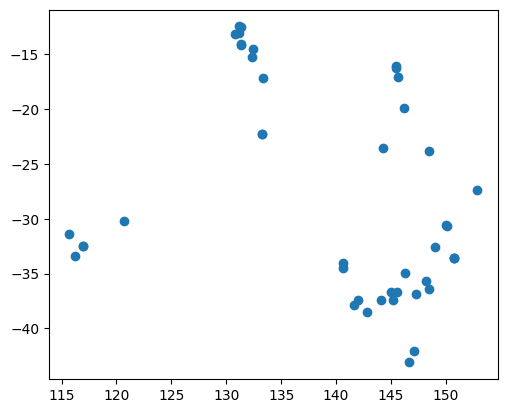

In [5]:
# plot sites
sites.plot()

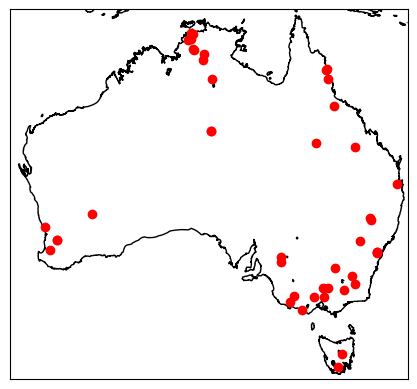

In [ ]:
from mpl_toolkits.basemap import Basemap

# create a map from Australia 
m = Basemap(projection='merc',llcrnrlat=-44,urcrnrlat=-10,\
            llcrnrlon=112,urcrnrlon=154,resolution='i')
# draw coastlines.
m.drawcoastlines()

# # convert latitude and longitude to x and y coordinates
x, y = m(sites['longitude'].values, sites['latitude'].values)
m.scatter(x, y, marker='o', color='Red', zorder=5)      

In [8]:
# List the dataset versions available for a site
versions = flux.get_versions("Boyagin")
versions

['2020',
 '2021_v1',
 '2022_v1',
 '2022_v2',
 '2023_v1',
 '2023_v2',
 '2024_v1',
 '2024_v2',
 '2025_v1',
 '2025_v2']

In [38]:
# Get processing-levels of a dataset for a specified site and version
levels = flux.get_processing_levels("Boyagin", "2025_v2")
levels

['L3', 'L4', 'L5', 'L6']

In [39]:
# Get global attributes for 30min dataset from a site
global_attributes = flux.get_global_attributes("Boyagin")
global_attributes

{'Conventions': 'CF-1.8',
 'acknowledgement': 'This work used eddy covariance data collected by the TERN Ecosystem \nProcesses facility. Ecosystem Processes would like to acknowledge the financial support of the \nAustralian Federal Government via the National Collaborative Research Infrastructure Scheme \nand the Education Investment Fund.',
 'altitude': '300m',
 'canopy_height': '13.0m',
 'comment': 'CF metadata, OzFlux standard variable names',
 'contact': 'jason.beringer@uwa.edu.au',
 'coverage_flux_L3': '87%',
 'coverage_meteorology_L3': '94%',
 'coverage_radiation_L3': '87%',
 'coverage_soil_L3': '96%',
 'data_link': 'http://data.ozflux.org.au/',
 'date_created': '2025-09-18 11:59:26',
 'featureType': 'timeSeries',
 'fluxnet_id': 'AU-Boy',
 'history': 'June 2021 processing',
 'institution': 'University of Western Australia',
 'latitude': '-32.477093',
 'license': 'https://creativecommons.org/licenses/by/4.0/',
 'license_name': 'CC BY 4.0',
 'longitude': '116.938559',
 'metadata_l

In [40]:
# Get variables of 30min dataset from a site 
flux.get_variables("Boyagin")

['crs',
 'station_name',
 'AH',
 'AH_QCFlag',
 'AH_HMP_23m',
 'AH_HMP_23m_QCFlag',
 'AH_IRGA_Av',
 'AH_IRGA_Av_QCFlag',
 'AH_IRGA_Sd',
 'AH_IRGA_Sd_QCFlag',
 'AH_IRGA_Vr',
 'AH_IRGA_Vr_QCFlag',
 'CO2',
 'CO2_QCFlag',
 'CO2_IRGA_Av',
 'CO2_IRGA_Av_QCFlag',
 'CO2_IRGA_Sd',
 'CO2_IRGA_Sd_QCFlag',
 'CO2_IRGA_Vr',
 'CO2_IRGA_Vr_QCFlag',
 'EC_05cma_N',
 'EC_05cma_N_QCFlag',
 'EC_05cma_S',
 'EC_05cma_S_QCFlag',
 'EC_05cmb_N',
 'EC_05cmb_N_QCFlag',
 'EC_05cmb_S',
 'EC_05cmb_S_QCFlag',
 'EC_08cm_main',
 'EC_08cm_main_QCFlag',
 'EC_10cma_N',
 'EC_10cma_N_QCFlag',
 'EC_10cma_S',
 'EC_10cma_S_QCFlag',
 'EC_10cmb_N',
 'EC_10cmb_N_QCFlag',
 'EC_10cmb_S',
 'EC_10cmb_S_QCFlag',
 'EC_110cm_N',
 'EC_110cm_N_QCFlag',
 'EC_110cm_S',
 'EC_110cm_S_QCFlag',
 'EC_15cm_main',
 'EC_15cm_main_QCFlag',
 'EC_20cma_N',
 'EC_20cma_N_QCFlag',
 'EC_20cma_S',
 'EC_20cma_S_QCFlag',
 'EC_20cmb_N',
 'EC_20cmb_N_QCFlag',
 'EC_20cmb_S',
 'EC_20cmb_S_QCFlag',
 'EC_40cm_N',
 'EC_40cm_N_QCFlag',
 'EC_40cm_S',
 'EC_40cm_S_QCFla

In [41]:
# Get 30min dataset variable's attribute
flux.get_attributes("Boyagin", "2025_v2", "L6", ["Fco2", "Fe", "Fh", "Fm"])

{'Fco2': {'_CoordinateAxes': 'time latitude longitude ',
  'coverage_L3': '82%',
  'coverage_L4': '82%',
  'coverage_L5': '100%',
  'coverage_L6': '100%',
  'description_L5': ', turbulence filter applied, gap filled using SOLO, SOLO',
  'height': '23m',
  'instrument': 'CSAT3, Li-7500A',
  'long_name': 'CO2 flux',
  'standard_name': 'surface_upward_mole_flux_of_carbon_dioxide',
  'statistic_type': 'average',
  'units': 'umol/m^2/s',
  'ustar_threshold_2017': '0.3585875511147041',
  'ustar_threshold_2018': '0.3527820230419159',
  'ustar_threshold_2019': '0.3727938963125518',
  'ustar_threshold_2020': '0.3534955989451564',
  'ustar_threshold_2021': '0.3611245579791773',
  'ustar_threshold_2022': '0.3605477819633439',
  'ustar_threshold_2023': '0.3238126490712655',
  'ustar_threshold_2024': '0.3753988048999009',
  'ustar_threshold_2025': '0.3687450967043207',
  'valid_range': array([-20.,  30.])},
 'Fe': {'_CoordinateAxes': 'time latitude longitude ',
  'coverage_L3': '85%',
  'coverage_L

In [13]:
# Get 30min dataset variable's attributes, default latest version and L3 processing-level
flux.get_attributes("Boyagin", variables=["AH", "CO2"])

{'AH': {'_CoordinateAxes': 'time latitude longitude ',
  'coverage_L3': '97%',
  'height': '23m',
  'instrument': 'HMP45',
  'long_name': 'Absolute humidity',
  'standard_name': 'mass_concentration_of_water_vapor_in_air',
  'statistic_type': 'average',
  'units': 'g/m^3',
  'valid_range': array([ 0., 40.])},
 'CO2': {'_CoordinateAxes': 'time latitude longitude ',
  'coverage_L3': '85%',
  'height': '23.0',
  'instrument': 'Li-7500A',
  'long_name': 'CO2 concentration',
  'standard_name': 'mole_fraction_of_carbon_dioxide_in_air',
  'statistic_type': 'average',
  'units': 'umol/mol',
  'valid_range': array([250., 900.])}}

In [14]:
# temporal range for 30min dataset (default)
flux.get_temporal_range("Boyagin", "2025_v2", "L6")


('2017-10-20T13:00:00.000000000', '2025-07-08T01:00:00.000000000')

In [42]:
# Get 30min dataset from a site, Output is a Xarray.Dataset
ds = flux.get_dataset("Boyagin", "2025_v2", "L3")
ds

<xarray.Dataset> Size: 202MB
Dimensions:               (time: 135241, latitude: 1, longitude: 1)
Coordinates:
  * time                  (time) datetime64[ns] 1MB 2017-10-20T13:00:00 ... 2...
  * latitude              (latitude) float64 8B -32.48
  * longitude             (longitude) float64 8B 116.9
Data variables: (12/250)
    crs                   int32 4B ...
    station_name          |S64 64B ...
    AH                    (time, latitude, longitude) float64 1MB ...
    AH_QCFlag             (time, latitude, longitude) int32 541kB ...
    AH_HMP_23m            (time, latitude, longitude) float64 1MB ...
    AH_HMP_23m_QCFlag     (time, latitude, longitude) int32 541kB ...
    ...                    ...
    Ws_SONIC_Av           (time, latitude, longitude) float64 1MB ...
    Ws_SONIC_Av_QCFlag    (time, latitude, longitude) int32 541kB ...
    ps                    (time, latitude, longitude) float64 1MB ...
    ps_QCFlag             (time, latitude, longitude) int32 541kB ...
    ustar                 (time, latitude, longitude) float64 1MB ...
    ustar_QCFlag          (time, latitude, longitude) int32 541kB ...
Attributes: (12/42)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    altitude:                 300m
    canopy_height:            13.0m
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    ...                       ...
    time_zone:                Australia/Perth
    title:                    Flux tower data set from the Boyagin site for t...
    tower_height:             30m
    vegetation:               Dry schlerophyll woodland
    DODS.strlen:              7
    DODS.dimName:             name_strlen

In [16]:
# Get 30min dataset from a site, and set missing value. Output is a Xarray.Dataset
import numpy as np
ds2 = flux.get_dataset("Boyagin", "2025_v2", "L3", missing_as_nan=True)

# print out the variables with na value, and a count of na
for var in list(ds2.variables.keys()):
  if var in list(ds2.coords) + ["crs", "station_name"]:
    continue
  fill_count = int(np.sum((ds[var] == -9999)).values)
  na_count = int(np.sum((np.isnan(ds[var]))).values)
  fill_count2 = int(np.sum((ds2[var] == -9999)).values)
  na_count2 = int(np.sum((np.isnan(ds2[var]))).values)
  if fill_count or na_count:
      print(f"{var}: fill: {fill_count2} ({fill_count}), na: {na_count2} ({na_count})")
    

AH: fill: 0 (3108), na: 3108 (0)
AH_HMP_23m: fill: 0 (3112), na: 3112 (0)
AH_IRGA_Av: fill: 0 (16606), na: 16606 (0)
AH_IRGA_Sd: fill: 0 (16605), na: 16605 (0)
AH_IRGA_Vr: fill: 0 (16605), na: 16605 (0)
CO2: fill: 0 (19005), na: 19005 (0)
CO2_IRGA_Av: fill: 0 (19005), na: 19005 (0)
CO2_IRGA_Sd: fill: 0 (16605), na: 16605 (0)
CO2_IRGA_Vr: fill: 0 (16726), na: 16726 (0)
EC_05cma_N: fill: 0 (8233), na: 8233 (0)
EC_05cma_S: fill: 0 (4478), na: 4478 (0)
EC_05cmb_N: fill: 0 (8233), na: 8233 (0)
EC_05cmb_S: fill: 0 (4478), na: 4478 (0)
EC_08cm_main: fill: 0 (10816), na: 10816 (0)
EC_10cma_N: fill: 0 (8233), na: 8233 (0)
EC_10cma_S: fill: 0 (4478), na: 4478 (0)
EC_10cmb_N: fill: 0 (8233), na: 8233 (0)
EC_10cmb_S: fill: 0 (4478), na: 4478 (0)
EC_110cm_N: fill: 0 (8233), na: 8233 (0)
EC_110cm_S: fill: 0 (4478), na: 4478 (0)
EC_15cm_main: fill: 0 (10816), na: 10816 (0)
EC_20cma_N: fill: 0 (8233), na: 8233 (0)
EC_20cma_S: fill: 0 (4478), na: 4478 (0)
EC_20cmb_N: fill: 0 (8233), na: 8233 (0)
EC_20c

In [26]:
# Get 30min datasets from 2 sites
datasets = flux.get_datasets(["Boyagin", "AliceSpringsMulga"] , "2025_v2", "L6")
datasets

{'Boyagin': <xarray.Dataset> Size: 230MB
 Dimensions:               (time: 135241, latitude: 1, longitude: 1)
 Coordinates:
   * time                  (time) datetime64[ns] 1MB 2017-10-20T13:00:00 ... 2...
   * latitude              (latitude) float64 8B -32.48
   * longitude             (longitude) float64 8B 116.9
 Data variables: (12/282)
     crs                   int32 4B ...
     station_name          |S64 64B ...
     AH                    (time, latitude, longitude) float64 1MB ...
     AH_QCFlag             (time, latitude, longitude) int32 541kB ...
     AH_HMP_23m            (time, latitude, longitude) float64 1MB ...
     AH_HMP_23m_QCFlag     (time, latitude, longitude) int32 541kB ...
     ...                    ...
     Ws_SONIC_Av           (time, latitude, longitude) float64 1MB ...
     Ws_SONIC_Av_QCFlag    (time, latitude, longitude) int32 541kB ...
     ps                    (time, latitude, longitude) float64 1MB ...
     ps_QCFlag             (time, latitude, lon

In [27]:
# Get a subset of 30min dataset, slice to 2 variables
subset = flux.get_subset("Boyagin",  "2025_v2", "L3", ["AH", "CO2"])
subset

<xarray.Dataset> Size: 4MB
Dimensions:     (time: 135241, latitude: 1, longitude: 1)
Coordinates:
  * time        (time) datetime64[ns] 1MB 2017-10-20T13:00:00 ... 2025-07-08T...
  * latitude    (latitude) float64 8B -32.48
  * longitude   (longitude) float64 8B 116.9
Data variables:
    AH          (time, latitude, longitude) float64 1MB ...
    CO2         (time, latitude, longitude) float64 1MB ...
    AH_QCFlag   (time, latitude, longitude) int32 541kB ...
    CO2_QCFlag  (time, latitude, longitude) int32 541kB ...
Attributes: (12/42)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    altitude:                 300m
    canopy_height:            13.0m
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    ...                       ...
    time_zone:                Australia/Perth
    title:                    Flux tower data set from the Boyagin site for t...
    tower_height:             30m
    vegetation:               Dry schlerophyll woodland
    DODS.strlen:              7
    DODS.dimName:             name_strlen

In [28]:
# Get a subset of 30min dataset from multiple sites, slice to 2 variables
subsets= flux.get_subsets(["Boyagin", "AliceSpringsMulga"],  "2025_v2", "L3", ["AH", "CO2"])
subsets

{'Boyagin': <xarray.Dataset> Size: 4MB
 Dimensions:     (time: 135241, latitude: 1, longitude: 1)
 Coordinates:
   * time        (time) datetime64[ns] 1MB 2017-10-20T13:00:00 ... 2025-07-08T...
   * latitude    (latitude) float64 8B -32.48
   * longitude   (longitude) float64 8B 116.9
 Data variables:
     AH          (time, latitude, longitude) float64 1MB ...
     CO2         (time, latitude, longitude) float64 1MB ...
     AH_QCFlag   (time, latitude, longitude) int32 541kB ...
     CO2_QCFlag  (time, latitude, longitude) int32 541kB ...
 Attributes: (12/42)
     Conventions:              CF-1.8
     acknowledgement:          This work used eddy covariance data collected b...
     altitude:                 300m
     canopy_height:            13.0m
     comment:                  CF metadata, OzFlux standard variable names
     contact:                  jason.beringer@uwa.edu.au
     ...                       ...
     time_zone:                Australia/Perth
     title:              

In [ ]:
# Get a subset of 30min dataset, slice to 2 variables, and temporal range 
subset = flux.get_subset("Boyagin",  "2025_v2", "L3", ["AH", "CO2"], start="2008-01-01 12:30", end="2008-12-31 00:00", keep_qcflags=False)
subset

<xarray.Dataset> Size: 420kB
Dimensions:    (time: 17496, latitude: 1, longitude: 1)
Coordinates:
  * time       (time) datetime64[ns] 140kB 2008-01-01T12:30:00 ... 2008-12-31
  * latitude   (latitude) float64 8B -13.08
  * longitude  (longitude) float64 8B 131.1
Data variables:
    AH         (time, latitude, longitude) float64 140kB ...
    CO2        (time, latitude, longitude) float64 140kB ...
Attributes: (12/40)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    canopy_height:            16.4m
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    coverage_flux_L3:         86%
    ...                       ...
    time_zone:                Australia/Darwin
    title:                    Flux tower data set from the Adelaide River sit...
    tower_height:             21m
    vegetation:               Woody Savanna
    DODS.strlen:              13
    DODS.dimName:             name_strlen

In [ ]:
# Save as netcdf file locally
from datetime import datetime
start = datetime.strptime("2008-1-1 12:30", "%Y-%m-%d %H:%M")
end = datetime.strptime("2008-11-30 00:00", "%Y-%m-%d %H:%M")
subset2 = flux.get_subset("Boyagin",  "2025_v2", "L3", ["AH", "CO2"], start, end, missing_as_nan=True)

# save data as netcdf file
subset2.to_netcdf("/Users/uqjsanc2/projects/terndata.flux/examples/subset2.nf")


In [ ]:
# Get 30-min dataset for a site
flux.get_l6_dataset("Boyagin", "2025_v2", "30min")

<xarray.Dataset> Size: 24MB
Dimensions:             (time: 28070, latitude: 1, longitude: 1)
Coordinates:
  * time                (time) datetime64[ns] 225kB 2007-10-17T11:30:00 ... 2...
  * latitude            (latitude) float64 8B -13.08
  * longitude           (longitude) float64 8B 131.1
Data variables: (12/142)
    crs                 int32 4B ...
    station_name        |S64 64B ...
    AH                  (time, latitude, longitude) float64 225kB ...
    AH_QCFlag           (time, latitude, longitude) int32 112kB ...
    AH_HMP_21m          (time, latitude, longitude) float64 225kB ...
    AH_HMP_21m_QCFlag   (time, latitude, longitude) int32 112kB ...
    ...                  ...
    Ws_SONIC_Av         (time, latitude, longitude) float64 225kB ...
    Ws_SONIC_Av_QCFlag  (time, latitude, longitude) int32 112kB ...
    ps                  (time, latitude, longitude) float64 225kB ...
    ps_QCFlag           (time, latitude, longitude) int32 112kB ...
    ustar               (time, latitude, longitude) float64 225kB ...
    ustar_QCFlag        (time, latitude, longitude) int32 112kB ...
Attributes: (12/53)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    canopy_height:            16.4m
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    controlfile_name:         controlfiles/OzFlux/Tower/L6/AdelaideRiver.txt
    ...                       ...
    time_zone:                Australia/Darwin
    title:                    Flux tower data set from the Adelaide River sit...
    tower_height:             21m
    vegetation:               Woody Savanna
    DODS.strlen:              13
    DODS.dimName:             name_strlen

In [ ]:
# Get daily dataset for a site
flux.get_l6_dataset("Boyagin", "2025_v2", "daily")

<xarray.Dataset> Size: 168kB
Dimensions:    (time: 584, latitude: 1, longitude: 1)
Coordinates:
  * time       (time) datetime64[ns] 5kB 2007-10-18T00:30:00 ... 2009-05-23T0...
  * latitude   (latitude) float64 8B -13.08
  * longitude  (longitude) float64 8B 131.1
Data variables: (12/35)
    AH         (time, latitude, longitude) float64 5kB ...
    CO2        (time, latitude, longitude) float64 5kB ...
    ER         (time, latitude, longitude) float64 5kB ...
    ER_LL      (time, latitude, longitude) float64 5kB ...
    ER_LT      (time, latitude, longitude) float64 5kB ...
    ER_SOLO    (time, latitude, longitude) float64 5kB ...
    ...         ...
    Ta         (time, latitude, longitude) float64 5kB ...
    Ts         (time, latitude, longitude) float64 5kB ...
    VP         (time, latitude, longitude) float64 5kB ...
    Ws         (time, latitude, longitude) float64 5kB ...
    ps         (time, latitude, longitude) float64 5kB ...
    ustar      (time, latitude, longitude) float64 5kB ...
Attributes: (12/51)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    canopy_height:            16.4m
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    controlfile_name:         controlfiles/OzFlux/Tower/L6/AdelaideRiver.txt
    ...                       ...
    time_coverage_start:      2007-10-17 11:30:00
    time_step:                daily
    time_zone:                Australia/Darwin
    title:                    Flux tower data set from the Adelaide River sit...
    tower_height:             21m
    vegetation:               Woody Savanna

In [ ]:
# Get monthly dataset for a site
flux.get_l6_dataset("Boyagin", "2025_v2", "monthly")

<xarray.Dataset> Size: 5kB
Dimensions:    (time: 19, latitude: 1, longitude: 1)
Coordinates:
  * time       (time) datetime64[ns] 152B 2007-11-01T00:30:00 ... 2009-05-01T...
  * latitude   (latitude) float64 8B -13.08
  * longitude  (longitude) float64 8B 131.1
Data variables: (12/35)
    AH         (time, latitude, longitude) float64 152B ...
    CO2        (time, latitude, longitude) float64 152B ...
    ER         (time, latitude, longitude) float64 152B ...
    ER_LL      (time, latitude, longitude) float64 152B ...
    ER_LT      (time, latitude, longitude) float64 152B ...
    ER_SOLO    (time, latitude, longitude) float64 152B ...
    ...         ...
    Ta         (time, latitude, longitude) float64 152B ...
    Ts         (time, latitude, longitude) float64 152B ...
    VP         (time, latitude, longitude) float64 152B ...
    Ws         (time, latitude, longitude) float64 152B ...
    ps         (time, latitude, longitude) float64 152B ...
    ustar      (time, latitude, longitude) float64 152B ...
Attributes: (12/51)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    canopy_height:            16.4m
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    controlfile_name:         controlfiles/OzFlux/Tower/L6/AdelaideRiver.txt
    ...                       ...
    time_coverage_start:      2007-10-17 11:30:00
    time_step:                monthly
    time_zone:                Australia/Darwin
    title:                    Flux tower data set from the Adelaide River sit...
    tower_height:             21m
    vegetation:               Woody Savanna

In [ ]:
# Get annual dataset for a site
flux.get_l6_dataset("Boyagin", "2025_v2", "annual")

<xarray.Dataset> Size: 904B
Dimensions:    (time: 3, latitude: 1, longitude: 1)
Coordinates:
  * time       (time) datetime64[ns] 24B 2007-01-01 2008-01-01 2009-01-01
  * latitude   (latitude) float64 8B -13.08
  * longitude  (longitude) float64 8B 131.1
Data variables: (12/36)
    AH         (time, latitude, longitude) float64 24B ...
    CO2        (time, latitude, longitude) float64 24B ...
    ER         (time, latitude, longitude) float64 24B ...
    ER_LL      (time, latitude, longitude) float64 24B ...
    ER_LT      (time, latitude, longitude) float64 24B ...
    ER_SOLO    (time, latitude, longitude) float64 24B ...
    ...         ...
    Ts         (time, latitude, longitude) float64 24B ...
    VP         (time, latitude, longitude) float64 24B ...
    Ws         (time, latitude, longitude) float64 24B ...
    nDays      (time, latitude, longitude) float64 24B ...
    ps         (time, latitude, longitude) float64 24B ...
    ustar      (time, latitude, longitude) float64 24B ...
Attributes: (12/51)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    canopy_height:            16.4m
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    controlfile_name:         controlfiles/OzFlux/Tower/L6/AdelaideRiver.txt
    ...                       ...
    time_coverage_start:      2007-10-17 11:30:00
    time_step:                annual
    time_zone:                Australia/Darwin
    title:                    Flux tower data set from the Adelaide River sit...
    tower_height:             21m
    vegetation:               Woody Savanna

In [ ]:
# Get cumulative dataset for a site
flux.get_l6_dataset("Boyagin", "2025_v2", "cumulative", missing_as_nan=True)

<xarray.Dataset> Size: 4MB
Dimensions:    (time: 28070, latitude: 1, longitude: 1)
Coordinates:
  * time       (time) datetime64[ns] 225kB 2007-10-17T11:30:00 ... 2009-05-24...
  * latitude   (latitude) float64 8B -13.08
  * longitude  (longitude) float64 8B 131.1
Data variables: (12/15)
    ER         (time, latitude, longitude) float64 225kB ...
    ER_LL      (time, latitude, longitude) float64 225kB ...
    ER_LT      (time, latitude, longitude) float64 225kB ...
    ER_SOLO    (time, latitude, longitude) float64 225kB ...
    ET         (time, latitude, longitude) float64 225kB ...
    GPP_LL     (time, latitude, longitude) float64 225kB ...
    ...         ...
    NEE_LT     (time, latitude, longitude) float64 225kB ...
    NEE_SOLO   (time, latitude, longitude) float64 225kB ...
    NEP_LL     (time, latitude, longitude) float64 225kB ...
    NEP_LT     (time, latitude, longitude) float64 225kB ...
    NEP_SOLO   (time, latitude, longitude) float64 225kB ...
    Precip     (time, latitude, longitude) float64 225kB ...
Attributes: (12/51)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    canopy_height:            16.4m
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  jason.beringer@uwa.edu.au
    controlfile_name:         controlfiles/OzFlux/Tower/L6/AdelaideRiver.txt
    ...                       ...
    time_coverage_start:      2007-10-17 11:30:00
    time_step:                30
    time_zone:                Australia/Darwin
    title:                    Flux tower data set from the Adelaide River sit...
    tower_height:             21m
    vegetation:               Woody Savanna

In [3]:
# Get non-existent dataset
flux.get_l6_dataset("CalperumChowilla", "2023_v2", "cumulative")

Exception: Error: fail to get L6 dataset for site 'CalperumChowilla', version '2023_v2': Requested 'cumulative' dataset is not found!

In [23]:
import os
os.getcwd()

'/Users/uqjsanc2/projects/terndata.flux/examples'

In [29]:
# export 30min dataset as oneflux csv;
flux.export_oneflux_csv("/Users/uqjsanc2/projects/terndata.flux/examples/data", "Boyagin", "2025_v2", "L3")

['/Users/uqjsanc2/projects/terndata.flux/examples/data/AU-Boy_qcv_2017.csv',
 '/Users/uqjsanc2/projects/terndata.flux/examples/data/AU-Boy_qcv_2018.csv',
 '/Users/uqjsanc2/projects/terndata.flux/examples/data/AU-Boy_qcv_2019.csv',
 '/Users/uqjsanc2/projects/terndata.flux/examples/data/AU-Boy_qcv_2020.csv',
 '/Users/uqjsanc2/projects/terndata.flux/examples/data/AU-Boy_qcv_2021.csv',
 '/Users/uqjsanc2/projects/terndata.flux/examples/data/AU-Boy_qcv_2022.csv',
 '/Users/uqjsanc2/projects/terndata.flux/examples/data/AU-Boy_qcv_2023.csv',
 '/Users/uqjsanc2/projects/terndata.flux/examples/data/AU-Boy_qcv_2024.csv',
 '/Users/uqjsanc2/projects/terndata.flux/examples/data/AU-Boy_qcv_2025.csv']

In [30]:
# export 30min dataset as Excel workbook;
flux.export_as_excel("/Users/uqjsanc2/projects/terndata.flux/examples/Boyagin_L3.xlsx", "Boyagin", "2025_v2", "L3")

'/Users/uqjsanc2/projects/terndata.flux/examples/Adelaide_L3.xlsx'

In [21]:
xds = flux.get_dataset("CalperumChowilla", "2025_v2", "L3", missing_as_nan=True)
xds

<xarray.Dataset> Size: 409MB
Dimensions:              (time: 264963, latitude: 1, longitude: 1)
Coordinates:
  * time                 (time) datetime64[ns] 2MB 2010-07-30T11:00:00 ... 20...
  * latitude             (latitude) float64 8B -34.0
  * longitude            (longitude) float64 8B 140.6
Data variables: (12/194)
    crs                  float64 8B ...
    station_name         object 8B ...
    AH                   (time, latitude, longitude) float64 2MB ...
    AH_QCFlag            (time, latitude, longitude) float64 2MB ...
    AH_HMP_2m            (time, latitude, longitude) float64 2MB ...
    AH_HMP_2m_QCFlag     (time, latitude, longitude) float64 2MB ...
    ...                   ...
    ps                   (time, latitude, longitude) float64 2MB ...
    ps_QCFlag            (time, latitude, longitude) float64 2MB ...
    ps_aux               (time, latitude, longitude) float64 2MB ...
    ps_aux_QCFlag        (time, latitude, longitude) float64 2MB ...
    ustar                (time, latitude, longitude) float64 2MB ...
    ustar_QCFlag         (time, latitude, longitude) float64 2MB ...
Attributes: (12/44)
    Conventions:              CF-1.8
    acknowledgement:          This work used eddy covariance data collected b...
    altitude:                 60m
    canopy_height:            3m
    comment:                  CF metadata, OzFlux standard variable names
    contact:                  ozfluxtech@adelaide.edu.au
    ...                       ...
    time_zone:                Australia/Adelaide
    title:                    Flux tower data set from the Calperum site for ...
    tower_height:             20m
    vegetation:               Mallee
    DODS.strlen:              8
    DODS.dimName:             name_strlen

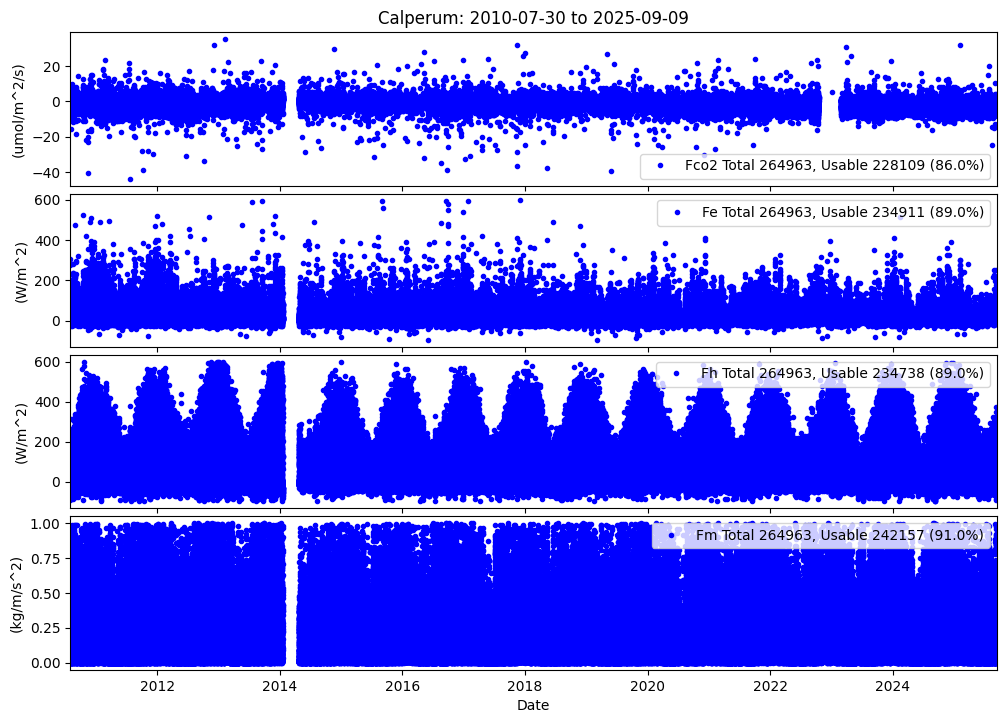

In [22]:
from terndata.flux import plot

# time-series plot
plot.plot_timeseries(xds, ["Fco2", "Fe", "Fh", "Fm"])

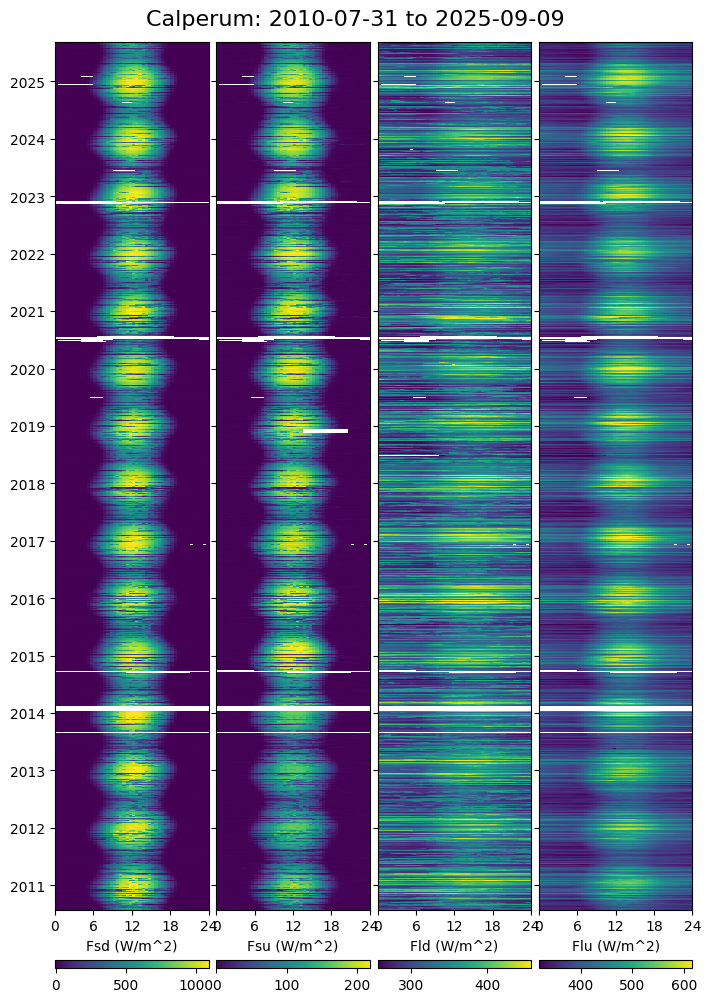

In [24]:
# Fingureprints plot
plot.plot_fingerprints(xds, ["Fsd", "Fsu", "Fld", "Flu"])